<a href="https://colab.research.google.com/github/LleilaA13/FDS25-26/blob/main/classnotes/NeuralNets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Before we start

Do yourself a favor: allow yourself to fall in love with neural networks.

Here are some awesome resources:
- Deep Learning (Goodfellow)
- Alice’s Adventures in a differentiable wonderland (Scardapane)
- Understanding Deep Learning (Prince)
- [3Blue1Brown](https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi)
- Computerphile Youtube Channel (all the Neural Nets series)
- ...

## 🧩 Simple MLP Implementation (from Scratch with NumPy)

This cell implements a **minimal Multi-Layer Perceptron (MLP)** using only NumPy — no deep learning libraries.

---

### ⚙️ Structure of the Network

The network has:
- **Input layer** of size `input_dim`
- **Hidden layer** with ReLU activation
- **Output layer** (linear)

Each layer has its own **weights** and **biases**:

$$
z_1 = XW_1 + b_1 \\
a_1 = \text{ReLU}(z_1) \\
z_2 = a_1 W_2 + b_2
$$

The final output is linear (no activation at the output layer).

---

### 🔁 Training Process

The model is trained with **Mean Squared Error (MSE)** loss and **manual backpropagation**:

1. **Forward pass:** compute intermediate activations and predictions  
2. **Backward pass:** compute gradients w.r.t. all parameters  
3. **Update step:** apply gradient descent to update $( W_1, b_1, W_2, b_2 )$

Learning rate controls the update magnitude.

---

### 🧠 ReLU Activation

The **ReLU** function introduces non-linearity:
$$
\text{ReLU}(x) = \max(0, x)
$$
Its derivative is:
$$
\text{ReLU}'(x) =
\begin{cases}
1, & x > 0 \\
0, & x \le 0
\end{cases}
$$

---

### 🧪 Example Task

Here, we train the model on a **simple identity mapping** task:  
the input is a one-hot vector (rows of the identity matrix),  
and the network learns to reproduce exactly the same output.

In [ ]:
import numpy as np

class SimpleMLP:
    def __init__(self, input_dim=10, hidden_dim=10, output_dim=10,
                 lr=0.05, seed=42):
        np.random.seed(seed)

        # Learning Rate:
        self.lr = lr

        # Neural Net:
        self.W1 = np.random.randn(input_dim, hidden_dim) * 0.1
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * 0.1
        self.b2 = np.zeros((1, output_dim))

    def relu(self, x):
        return np.maximum(0, x)

    def relu_deriv(self, x):
        return (x > 0).astype(float)

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        return self.z2  # linear output

    def backward(self, X, y, y_pred):
        grad_y_pred = 2 * (y_pred - y) / y.size
        grad_W2 = self.a1.T @ grad_y_pred
        grad_b2 = np.sum(grad_y_pred, axis=0, keepdims=True)
        grad_a1 = grad_y_pred @ self.W2.T
        grad_z1 = grad_a1 * self.relu_deriv(self.z1)
        grad_W1 = X.T @ grad_z1
        grad_b1 = np.sum(grad_z1, axis=0, keepdims=True)

        # Gradient descent update
        self.W1 -= self.lr * grad_W1
        self.b1 -= self.lr * grad_b1
        self.W2 -= self.lr * grad_W2
        self.b2 -= self.lr * grad_b2

    def train(self, X, y, epochs=5000, verbose=True):
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = np.mean((y_pred - y)**2)
            self.backward(X, y, y_pred)
            if verbose and epoch % 500 == 0:
                print(f"Epoch {epoch}: Loss = {loss:.6f}")
        return self

# --------------------
# Example usage
# --------------------
X = np.eye(10)
y = X.copy()

mlp = SimpleMLP(input_dim=10, hidden_dim=10, output_dim=10, lr=0.05)
mlp.train(X, y)

preds = mlp.forward(X)

Epoch 0: Loss = 0.100017
Epoch 500: Loss = 0.082956
Epoch 1000: Loss = 0.072390
Epoch 1500: Loss = 0.057797
Epoch 2000: Loss = 0.043082
Epoch 2500: Loss = 0.030405
Epoch 3000: Loss = 0.019949
Epoch 3500: Loss = 0.011586
Epoch 4000: Loss = 0.005596
Epoch 4500: Loss = 0.002242


In [ ]:
print("\nPredictions, round(2):")
print(np.round(preds, 2))


Predictions, round(2):
[[ 0.9   0.04  0.01 -0.03  0.02  0.06  0.01 -0.02  0.07 -0.02]
 [ 0.07  0.83  0.03 -0.    0.01 -0.01 -0.01 -0.02  0.03  0.01]
 [-0.    0.01  0.97 -0.    0.03 -0.    0.   -0.    0.02 -0.  ]
 [-0.02  0.02 -0.01  0.99  0.    0.    0.   -0.01  0.02 -0.  ]
 [ 0.03 -0.02  0.01 -0.    0.92  0.01  0.02  0.02 -0.03  0.01]
 [ 0.01  0.01 -0.    0.01 -0.    0.98 -0.01  0.   -0.02  0.  ]
 [ 0.01  0.01 -0.    0.01  0.01 -0.01  0.99  0.01 -0.01  0.  ]
 [-0.    0.01 -0.    0.    0.    0.    0.    1.    0.01  0.  ]
 [ 0.03 -0.    0.02  0.02 -0.02 -0.01 -0.01  0.01  0.95  0.01]
 [-0.01  0.02 -0.01  0.    0.03  0.    0.   -0.    0.01  0.99]]


In [ ]:
print("\nPredictions, round(4):")
print(np.round(preds, 4))


Predictions, round(4):
[[ 9.000e-01  3.710e-02  1.240e-02 -3.350e-02  2.230e-02  5.720e-02
   1.140e-02 -2.240e-02  7.170e-02 -2.080e-02]
 [ 7.220e-02  8.302e-01  2.720e-02 -1.000e-03  7.600e-03 -6.400e-03
  -8.200e-03 -2.050e-02  2.850e-02  1.430e-02]
 [-4.800e-03  1.400e-02  9.705e-01 -1.700e-03  2.690e-02 -4.400e-03
   1.900e-03 -3.200e-03  1.570e-02 -4.600e-03]
 [-2.050e-02  1.860e-02 -1.130e-02  9.907e-01  1.500e-03  3.400e-03
   2.900e-03 -5.400e-03  2.070e-02 -2.000e-04]
 [ 2.650e-02 -2.190e-02  1.360e-02 -2.000e-03  9.237e-01  9.700e-03
   2.420e-02  1.510e-02 -3.050e-02  1.120e-02]
 [ 1.260e-02  6.100e-03 -4.400e-03  5.100e-03 -3.600e-03  9.793e-01
  -9.400e-03  4.900e-03 -1.840e-02  1.200e-03]
 [ 8.700e-03  7.100e-03 -3.500e-03  5.600e-03  8.700e-03 -9.500e-03
   9.914e-01  6.800e-03 -9.900e-03  1.300e-03]
 [-1.000e-03  7.000e-03 -2.000e-03  1.100e-03  4.500e-03  5.000e-04
   2.800e-03  9.961e-01  6.100e-03  1.600e-03]
 [ 3.270e-02 -2.400e-03  2.020e-02  1.650e-02 -2.160e-02

## Why the ReLU?

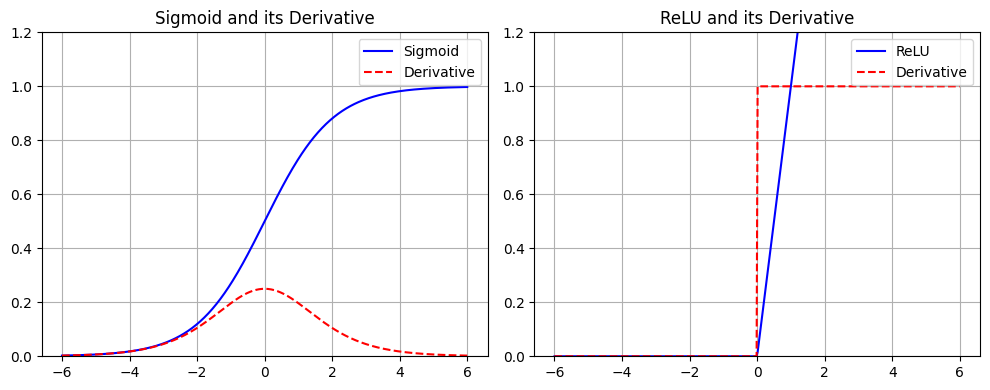

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Activation functions and derivatives ---
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1 - s)

def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(float)

# --- Range ---
x = np.linspace(-6, 6, 400)

# --- Compute values ---
sig = sigmoid(x)
sig_d = sigmoid_deriv(x)
re = relu(x)
re_d = relu_deriv(x)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Sigmoid
axes[0].plot(x, sig, label="Sigmoid", color="blue")
axes[0].plot(x, sig_d, label="Derivative", color="red", linestyle="--")
axes[0].set_ylim(0, 1.2)
axes[0].set_title("Sigmoid and its Derivative")
axes[0].legend()
axes[0].grid(True)

# ReLU
axes[1].plot(x, re, label="ReLU", color="blue")
axes[1].plot(x, re_d, label="Derivative", color="red", linestyle="--")
axes[1].set_ylim(0, 1.2)
axes[1].set_title("ReLU and its Derivative")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


### Alternatives to ReLU:

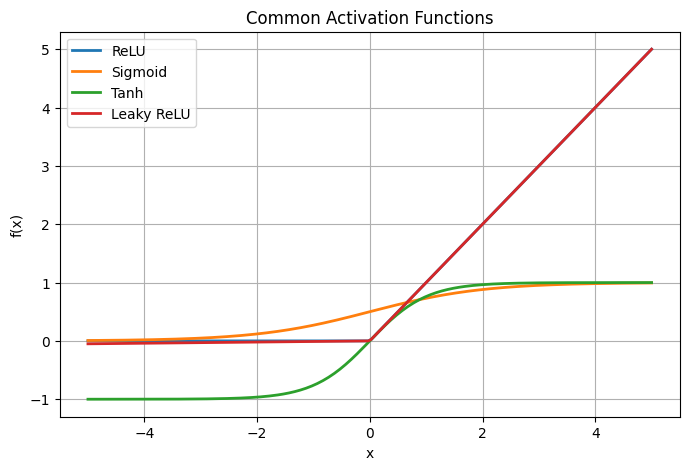

In [ ]:
# --- Common Activation Functions (without derivatives) ---
import numpy as np
import matplotlib.pyplot as plt

def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

# --- Visualization ---
x = np.linspace(-5, 5, 200)

activations = {
    "ReLU": relu(x),
    "Sigmoid": sigmoid(x),
    "Tanh": tanh(x),
    "Leaky ReLU": leaky_relu(x)
}

plt.figure(figsize=(8, 5))
for name, y in activations.items():
    plt.plot(x, y, label=name, linewidth=2)
plt.title("Common Activation Functions")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

(See Fig. 3.13 of Understanding Deep Learning)

## MLP with torch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# ----------------------------
# Dataset: all one-hot vectors
# ----------------------------
X = torch.eye(10)
y = X.clone()

# ----------------------------
# Define the MLP model
# ----------------------------
class SimpleMLP(nn.Module):
    def __init__(self, input_dim=10, hidden_dim=10, output_dim=10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# ----------------------------
# Instantiate model, loss, optimizer
# ----------------------------
model = SimpleMLP(input_dim=10, hidden_dim=16, output_dim=10)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.05)

# ----------------------------
# Training loop
# ----------------------------
epochs = 5000
for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model(X)
    loss = criterion(y_pred, y)
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.6f}")

# ----------------------------
# Test reconstruction
# ----------------------------
with torch.no_grad():
    preds = model(X)
print("\nPredictions:")
print(torch.round(preds, decimals=2))


Epoch 0: Loss = 0.151979
Epoch 500: Loss = 0.069396
Epoch 1000: Loss = 0.048408
Epoch 1500: Loss = 0.032101
Epoch 2000: Loss = 0.019440
Epoch 2500: Loss = 0.009691
Epoch 3000: Loss = 0.003686
Epoch 3500: Loss = 0.001106
Epoch 4000: Loss = 0.000305
Epoch 4500: Loss = 0.000087

Predictions:
tensor([[ 0.9900,  0.0000, -0.0000, -0.0000, -0.0000, -0.0000, -0.0000,  0.0000,
         -0.0000,  0.0000],
        [ 0.0000,  1.0000,  0.0000,  0.0000, -0.0000, -0.0000, -0.0000,  0.0100,
          0.0100,  0.0000],
        [-0.0000, -0.0000,  0.9900, -0.0000, -0.0000, -0.0100, -0.0000,  0.0000,
         -0.0000,  0.0000],
        [-0.0000, -0.0000,  0.0000,  1.0000,  0.0000,  0.0100,  0.0000, -0.0000,
          0.0000, -0.0100],
        [-0.0000, -0.0000,  0.0000, -0.0000,  1.0000,  0.0000,  0.0000, -0.0000,
         -0.0000, -0.0000],
        [-0.0000, -0.0000, -0.0000, -0.0000, -0.0000,  0.9900, -0.0000, -0.0000,
         -0.0000,  0.0000],
        [ 0.0100,  0.0000,  0.0000,  0.0100,  0.0100,  0

## Optimizers

## 🔧 Optimizers in Neural Networks

During training, **optimizers** update the model’s parameters to minimize the loss function by following the gradient direction.  
Different optimizers control how these updates happen — some use only the current gradient, while others keep track of past gradients or adapt learning rates.

---

### 1. **SGD (Stochastic Gradient Descent)**
Updates weights using the raw gradient:
$$
\theta_{t+1} = \theta_t - \eta \nabla_\theta L(\theta_t)
$$
Simple and effective, but may oscillate or converge slowly.

With **momentum**, the update accumulates past gradients:
$$
v_t = \beta v_{t-1} + (1 - \beta)\nabla_\theta L(\theta_t)
$$
$$
\theta_{t+1} = \theta_t - \eta v_t
$$

---

### 2. **Momentum**
Looks ahead before applying the gradient, often improving convergence:
$$
v_t = \beta v_{t-1} + \eta \nabla_\theta L(\theta_t - \beta v_{t-1})
$$

---

### 3. **RMSProp**
Adapts the learning rate for each parameter using a moving average of squared gradients:
$$
s_t = \rho s_{t-1} + (1 - \rho)(\nabla_\theta L(\theta_t))^2
$$
$$
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{s_t + \epsilon}} \nabla_\theta L(\theta_t)
$$

---

### 4. **Adam (Adaptive Moment Estimation)**
Combines **momentum** and **RMSProp**:
$$
m_t = \beta_1 m_{t-1} + (1 - \beta_1)\nabla_\theta L(\theta_t)
$$
$$
v_t = \beta_2 v_{t-1} + (1 - \beta_2)(\nabla_\theta L(\theta_t))^2
$$
$$
\theta_{t+1} = \theta_t - \frac{\eta\, m_t / (1 - \beta_1^t)}{\sqrt{v_t / (1 - \beta_2^t)} + \epsilon}
$$

---

### 5. **AdamW**
A modification of Adam that decouples weight decay (regularization) from the update rule.  
Preferred in transformers and diffusion models.

---

### 🧭 Summary

| Optimizer | Momentum | Adaptive LR | Typical Use |
|------------|-----------|--------------|--------------|
| SGD        | ❌ / ✅ | ❌ | Simple models, baselines |
| RMSProp    | ✅ | ✅ | RNNs, noisy gradients |
| Adam       | ✅ | ✅ | Most deep learning models |
| AdamW      | ✅ | ✅ | Transformers, diffusion, vision models |

In PyTorch:
```python
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


# 🧠 Dropout in Neural Networks

**Dropout** is one of the simplest and most effective techniques to prevent **overfitting** in neural networks.  
The idea is intuitive: during training, we **randomly deactivate** a fraction of neurons in the network, forcing the model to avoid relying too heavily on any single neuron or pathway.

---

## 🔍 Why Dropout?

When training deep models, neurons tend to **co-adapt** — they learn to correct each other’s mistakes.  
This makes the network fragile: it performs very well on the training data but fails to generalize to unseen inputs.

Dropout acts as a regularizer:
- At each training step, some neurons are **temporarily “dropped out”** (set to zero).
- This means the network must **distribute learning across multiple neurons**, not just a few dominant ones.
- At inference time (evaluation), all neurons are active, but their outputs are scaled to compensate for the missing ones during training.

Mathematically, if the dropout rate is \( p = 0.2 \), each neuron has an 80% chance of being kept active during training.

---

## 🧩 Effect on Learning

- **Without dropout**: the model may learn a very *specific* mapping that fits the training data perfectly but generalizes poorly.  
- **With dropout**: the model learns a more *robust and smoother* approximation of the true function.

---

## 🎯 How Dropout Works at Inference Time

During **training**, dropout randomly *turns off* a fraction \( p \) of neurons at each forward pass.  
Each active neuron is scaled by \( \frac{1}{1-p} \) to keep the expected activation level constant.  
This is known as **inverted dropout**.

Mathematically:

$$
\tilde{h}_i =
\begin{cases}
\dfrac{h_i}{1-p}, & \text{with probability } (1-p) \\
0, & \text{with probability } p
\end{cases}
$$

---

### 🧮 During Inference (Evaluation)

At inference time:
- **No neurons are dropped.**
- **No rescaling is required.**
- The model behaves deterministically, using all neurons together.

In PyTorch:

```python
model.train()   # activates dropout
model.eval()    # disables dropout

Please, look at Section 7.12 of Deep Learning by Goodfellow:

> *Each time we load an example into a minibatch, we randomly sample a different binary mask to apply to all of the input and hidden units in the network.*

> *Dropout training is not quite the same as bagging training. In the case of bagging, the models are all independent. In the case of dropout, the models share parameters [...]. This parameter sharing makes it possible to represent an exponential number of models with a tractable amount of memory. In the case of bagging, each model is trained to convergence on its respective training set.*


Epoch 0, loss = 0.1197
Epoch 400, loss = 0.0061
Epoch 800, loss = 0.0047
Epoch 1200, loss = 0.0050
Epoch 1600, loss = 0.0049


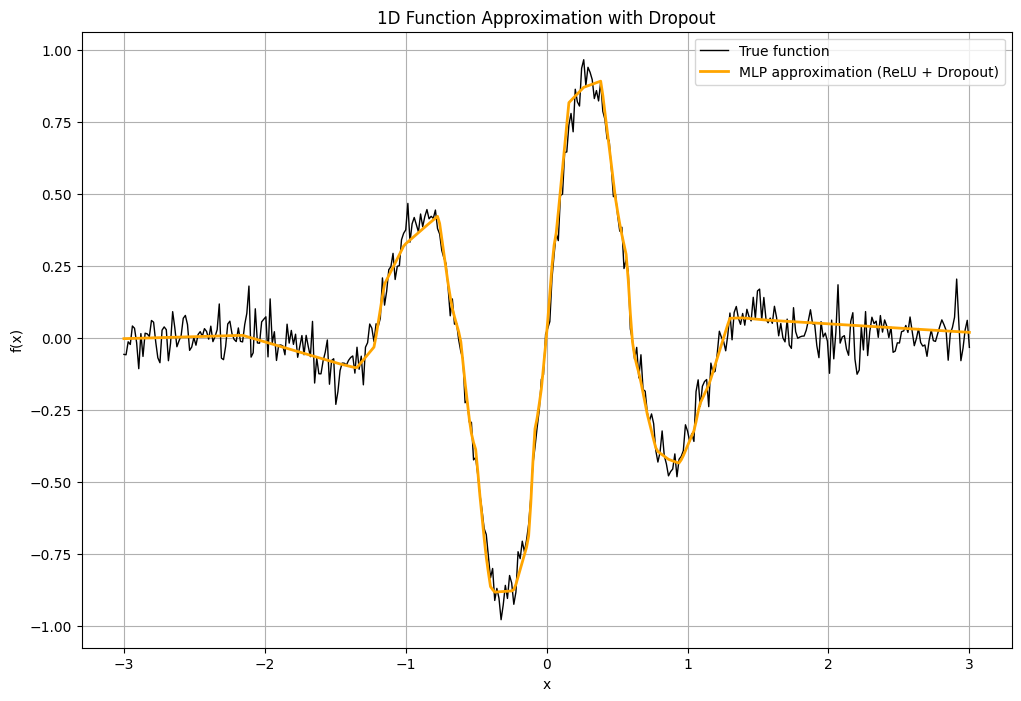

In [ ]:
# --- Imports ---
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# --- Generate 1D data ---
torch.manual_seed(0)
x = torch.linspace(-3, 3, 400).unsqueeze(1)
y = torch.sin(5 * x) * torch.exp(-x**2) + 0.05 * torch.randn_like(x)

# --- Define small MLP with Dropout ---
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

model = MLP()
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

# --- Training ---
for epoch in range(2000):
    optimizer.zero_grad()
    y_pred = model(x)
    loss = loss_fn(y_pred, y)
    loss.backward()
    optimizer.step()
    if epoch % 400 == 0:
        print(f"Epoch {epoch}, loss = {loss.item():.4f}")

# --- Evaluate model ---
model.eval()
with torch.no_grad():
    y_hat = model(x)

# --- Plot ---
plt.figure(figsize=(12,8))
plt.plot(x, y, label="True function", color="black", linewidth=1)
plt.plot(x, y_hat, label="MLP approximation (ReLU + Dropout)", color="orange", linewidth=2)
plt.title("1D Function Approximation with Dropout")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()
